In [31]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent))  # "Programming Part" auf sys.path

from env import gymnasium_env as drausp_env
import numpy as np

from env.instance_reader import get_instance_data
import matplotlib.pyplot as plt

data_path = Path("../../instances/lion18s/SB03.txt")

In [32]:
DRAUSP_data = get_instance_data(data_path)

K = DRAUSP_data.num_slots
T_d = 50  # Anzahl Anfragen pro Episode
C_k = DRAUSP_data.capacity_vector
instance = DRAUSP_data.instance
request_lengths = DRAUSP_data.request_length
pool_size = DRAUSP_data.pool_size

print(K)
print(T_d)
print(pool_size)

print(C_k)
print(instance)

8
50
50
[10, 10, 10, 10, 10, 10, 10, 10]
[[0.414, 1, 1, 2, 1, 0, 0, 0, 0], [0.39, 2, 1, 2, 1, 0, 0, 0, 0], [0.205, 3, 1, 1, 2, 0, 0, 0, 0], [0.614, 1, 2, 1, 1, 0, 0, 0, 0], [0.184, 1, 1, 1, 3, 0, 0, 0, 0], [0.236, 1, 1, 1, 1, 0, 0, 0, 0], [0.255, 3, 3, 1, 1, 0, 0, 0, 0], [0.137, 2, 1, 2, 2, 0, 0, 0, 0], [0.779, 1, 1, 1, 1, 0, 0, 0, 0], [0.089, 2, 1, 1, 1, 0, 0, 0, 0], [0.258, 2, 2, 1, 1, 0, 0, 0, 0], [0.747, 1, 1, 1, 1, 0, 0, 0, 0], [0.393, 1, 1, 1, 2, 0, 0, 0, 0], [0.544, 1, 1, 2, 1, 0, 0, 0, 0], [0.701, 1, 1, 1, 1, 0, 0, 0, 0], [0.718, 1, 1, 1, 1, 0, 0, 0, 0], [0.552, 1, 2, 1, 3, 0, 0, 0, 0], [0.092, 3, 2, 2, 1, 0, 0, 0, 0], [0.961, 1, 1, 1, 1, 0, 0, 0, 0], [0.639, 3, 1, 2, 1, 0, 0, 0, 0], [0.502, 1, 1, 1, 1, 0, 0, 0, 0], [0.205, 2, 1, 2, 2, 0, 0, 0, 0], [0.432, 1, 1, 1, 1, 0, 0, 0, 0], [0.74, 1, 2, 1, 4, 0, 0, 0, 0], [0.628, 1, 1, 2, 1, 0, 0, 0, 0], [0.603, 1, 1, 1, 1, 0, 0, 0, 0], [0.222, 1, 2, 3, 1, 0, 0, 0, 0], [0.812, 2, 1, 1, 1, 0, 0, 0, 0], [0.924, 1, 1, 2, 1, 0, 0, 0, 0], [0.

In [33]:
env = drausp_env.DrauspEnv(K=K, T_d=T_d, C_k=C_k, instance=instance, render_mode="human", fixed_request_length=request_lengths)

In [34]:
from training.dqn_agent import DQNAgent
from models.deep_lattice import DeepLatticeNetwork


agent = DQNAgent(
    env,
    QnetworkClass=lambda input_dim, output_dim: DeepLatticeNetwork(
        input_dim     = input_dim,
        output_dim    = output_dim,
        c_range       = (0.0, 10.0),
        t_range       = (1.0, float(T_d)),
        r_range       = (0.0, 1.0),
        q_range       = (0.0, 10.0)
    ),
    monotonicity_penalty=False,
    reject_bias=0.75,
    gamma=0.99,
    epsilon_decay_steps=50000
,)

In [35]:

reward_history, monotonicity_violations, depth_history = agent.train(num_episodes=10000)

  Systematic monotonicity (Episode 1): C_k: 100.0%, t: 100.0%, r: 100.0%, q: 100.0%, mixed: 100.0%
Episode   50/10000  Reward:     4.67  Avg(50):     4.81  Tiefe:   33  Avg-Tiefe(50):   37.7  ε: 0.965
  Systematic monotonicity (Episode 51): C_k: 100.0%, t: 100.0%, r: 100.0%, q: 100.0%, mixed: 100.0%
Episode  100/10000  Reward:     5.26  Avg(50):     4.63  Tiefe:   36  Avg-Tiefe(50):   33.8  ε: 0.934
  Systematic monotonicity (Episode 101): C_k: 100.0%, t: 100.0%, r: 100.0%, q: 100.0%, mixed: 100.0%
Episode  150/10000  Reward:     3.87  Avg(50):     4.70  Tiefe:   29  Avg-Tiefe(50):   31.2  ε: 0.907
  Systematic monotonicity (Episode 151): C_k: 100.0%, t: 100.0%, r: 100.0%, q: 100.0%, mixed: 100.0%
Episode  200/10000  Reward:     7.20  Avg(50):     5.31  Tiefe:   41  Avg-Tiefe(50):   36.4  ε: 0.877
  Systematic monotonicity (Episode 201): C_k: 100.0%, t: 100.0%, r: 100.0%, q: 100.0%, mixed: 100.0%
Episode  250/10000  Reward:     4.84  Avg(50):     5.40  Tiefe:   33  Avg-Tiefe(50):   35.

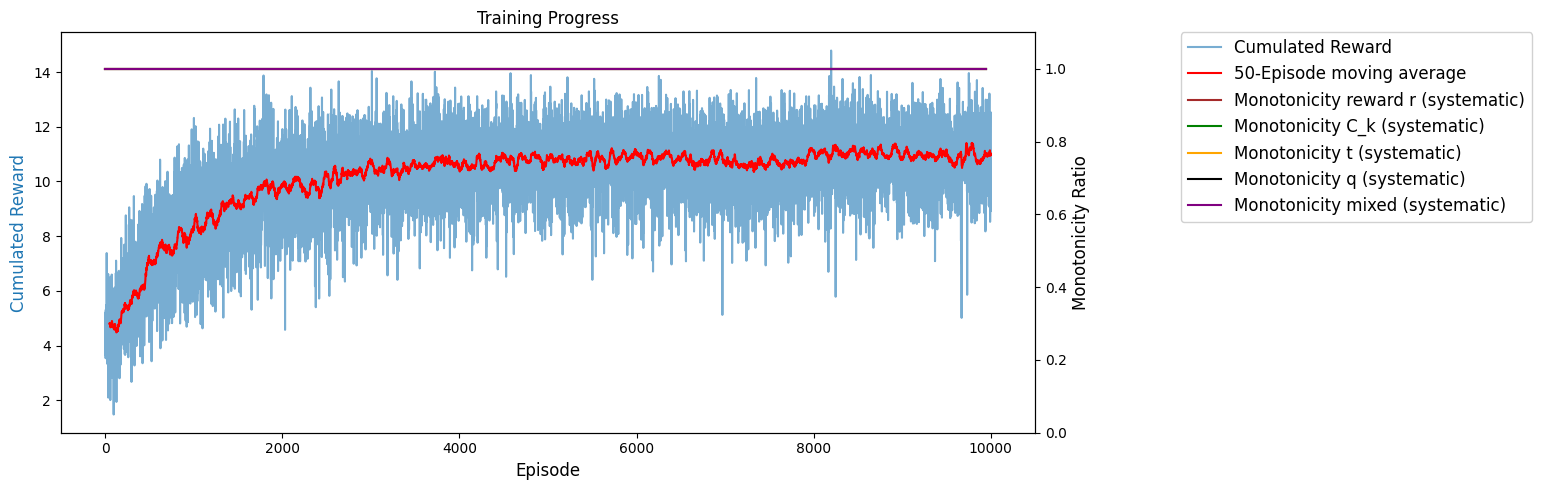

In [36]:
from training.plotting import plot_training_progress, plot_depth_epsilon

plot_training_progress(reward_history, monotonicity_violations)

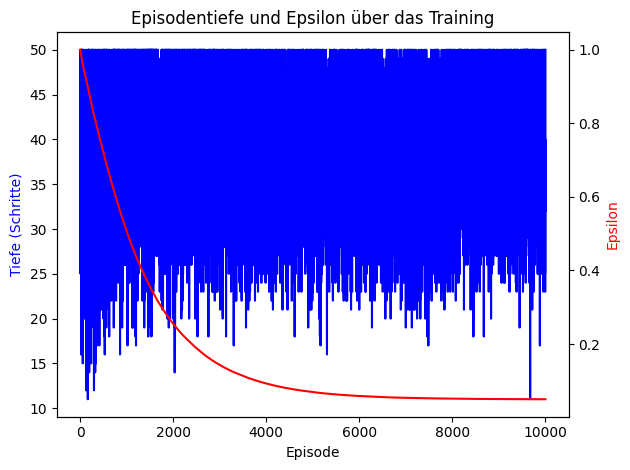

In [37]:
plot_depth_epsilon(depth_history)

Episoden: 10000
Mean: 10.1583, Std: 1.8012, Median: 10.5020
Max: 14.7860, Min: 1.4840


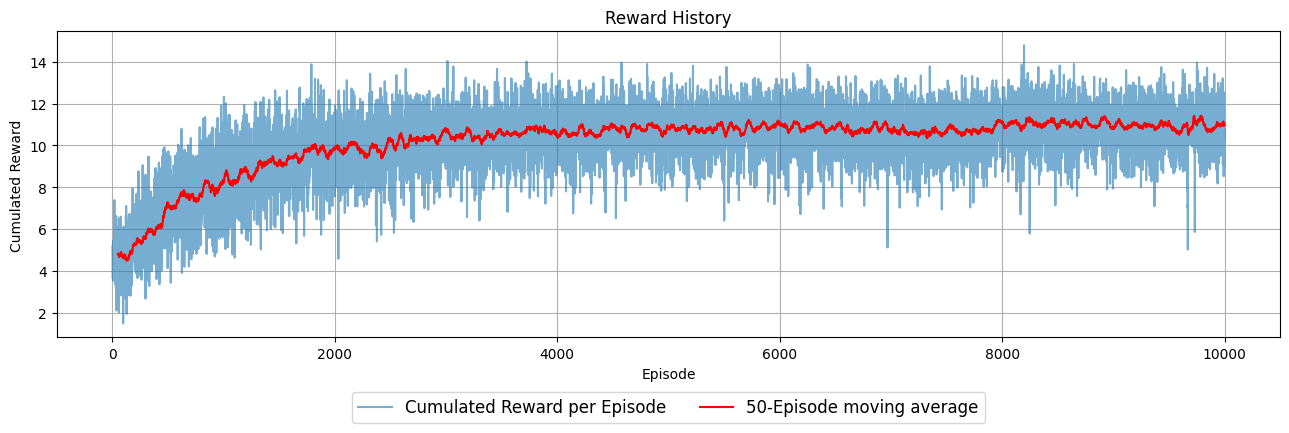

{'n': 10000,
 'mean': 10.158330345086009,
 'std': 1.8012122245797721,
 'median': 10.502000123262405,
 'max': 14.78600025177002,
 'min': 1.4840000048279762}

In [38]:
from training.plotting import plot_reward_moving_average
plot_reward_moving_average(reward_history, window=50)

## Evaluationsphase (eingefrorene Parameter, epsilon=0)

Nach abgeschlossenem Training werden die Netzgewichte fixiert (keine weiteren Trainingsschritte, `epsilon=0`, reines Exploitation) und für 10.000 Episoden evaluiert, um eine stabile Schätzung der Performance zu erhalten.

In [39]:
eval_rewards, eval_depths = agent.evaluate(num_episodes=10000)

[Eval] Episode   500/10000  Reward:    11.24  Avg(500):    11.05  Avg-Tiefe(500):   36.1
[Eval] Episode  1000/10000  Reward:    11.12  Avg(500):    11.04  Avg-Tiefe(500):   36.2
[Eval] Episode  1500/10000  Reward:    10.96  Avg(500):    11.09  Avg-Tiefe(500):   35.9
[Eval] Episode  2000/10000  Reward:    11.50  Avg(500):    11.14  Avg-Tiefe(500):   36.8
[Eval] Episode  2500/10000  Reward:    10.66  Avg(500):    11.00  Avg-Tiefe(500):   35.7
[Eval] Episode  3000/10000  Reward:    10.82  Avg(500):    11.12  Avg-Tiefe(500):   35.9
[Eval] Episode  3500/10000  Reward:     9.38  Avg(500):    11.01  Avg-Tiefe(500):   35.9
[Eval] Episode  4000/10000  Reward:    11.16  Avg(500):    11.05  Avg-Tiefe(500):   35.5
[Eval] Episode  4500/10000  Reward:    10.94  Avg(500):    11.08  Avg-Tiefe(500):   36.1
[Eval] Episode  5000/10000  Reward:    12.22  Avg(500):    11.07  Avg-Tiefe(500):   35.7
[Eval] Episode  5500/10000  Reward:    11.60  Avg(500):    11.11  Avg-Tiefe(500):   36.4
[Eval] Episode  6000/

Eval-Episoden: 10000
Mean: 11.0660, Std: 0.9195, Median: 11.0980
Max: 14.7070, Min: 7.4890


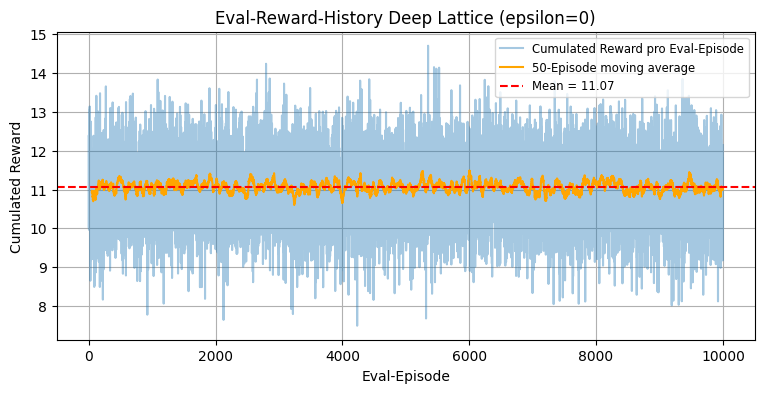

In [40]:
from training.plotting import plot_eval_rewards

eval_stats = plot_eval_rewards(eval_rewards, title="Eval-Reward-History Deep Lattice (epsilon=0)")